In [1]:
import jax
import jax.random as jr
import jax.numpy as jnp

import sys
sys.path.insert(0, "..")

from bayesoptax.loop import run, run_seeds

In [2]:
def ackley(x: jax.Array) -> jax.Array:
    sum1 = jnp.mean(x ** 2)
    sum2 = jnp.mean(jnp.cos(2 * jnp.pi * x))
    val = -20 * jnp.exp(-0.2 * jnp.sqrt(sum1)) - jnp.exp(sum2) + 20 + jnp.e
    return val

In [ ]:
D = 12
bounds = jnp.tile(jnp.array([-10.0, 10.0]), (D, 1))

results = run_seeds(
    objective=ackley,
    bounds=bounds,
    n_seeds=10,
    n_init=5*D,
    n_iter=200,
    kernel_name="matern52",
    acquisition_name="ts",
)

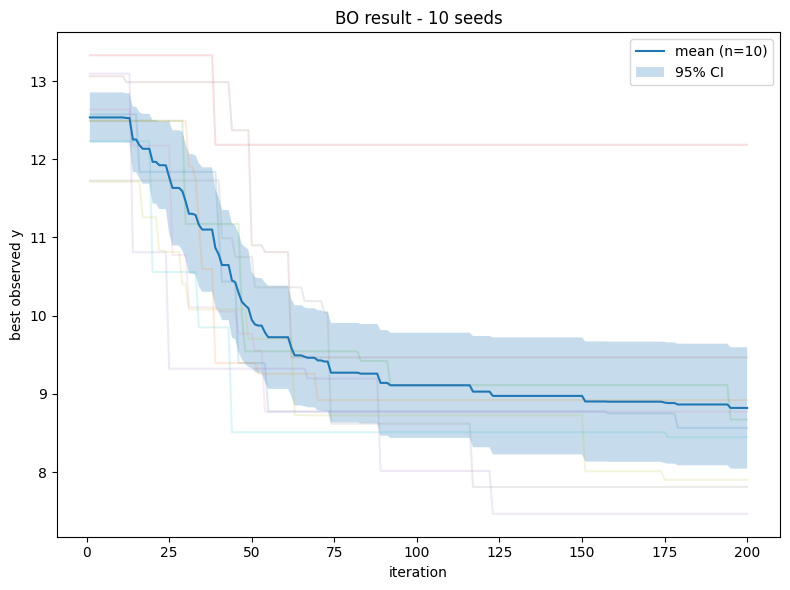

In [4]:
results.plot()